# Treinamento com Configuração Comprovada (R² = 0.84)\n
Voltamos à configuração exata que bateu 0.84: 54 features (sem variáveis auxiliares), janela de 20s, amostragem de 40% com shuffle, e rede de 256->128->64.

In [6]:
import os
import h5py
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 1. Carregando os Dados e Gerando Features Temporais (54 Colunas)

In [7]:
# Carregar arquivo
filename = 'data/N-CMAPSS_DS02-006.h5'
with h5py.File(filename, 'r') as hdf:
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))
    Y_dev = np.array(hdf.get('Y_dev'))
    A_dev = np.array(hdf.get('A_dev'))
    
    W_test = np.array(hdf.get('W_test'))
    X_s_test = np.array(hdf.get('X_s_test'))
    Y_test = np.array(hdf.get('Y_test'))
    A_test = np.array(hdf.get('A_test'))

def create_temporal_features_safe(W, X_s, Y, A, window=20):
    # Apenas Sensores e Condições de voo. Sem a matriz A (nem ciclo, nem classe)
    matriz_base = np.concatenate((W, X_s), axis=1).astype('float32')
    
    df = pd.DataFrame(matriz_base)
    df['unit'] = A[:, 0].astype('float32') # Unidade só para o groupby
    df['RUL'] = Y.flatten().astype('float32')
    
    print("Calculando médias e variâncias (Janela=20)...")
    df_mean = df.groupby('unit').rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True).sort_index().astype('float32')
    df_var = df.groupby('unit').rolling(window=window, min_periods=1).var().fillna(0).reset_index(level=0, drop=True).sort_index().astype('float32')
    
    df_mean = df_mean[df.columns[:-2]]
    df_var = df_var[df.columns[:-2]]
    df_raw = pd.DataFrame(matriz_base)
    
    X_temporal = pd.concat([df_raw, df_mean, df_var], axis=1).values.astype('float32')
    y_labels = df['RUL'].values.astype('float32')
    
    del df, df_mean, df_var, df_raw, matriz_base
    gc.collect()
    
    return X_temporal, y_labels

print("Processando Treino (Configuração de 54 features)...")
X_train_raw, y_train_full = create_temporal_features_safe(W_dev, X_s_dev, Y_dev, A_dev, window=20)

print("Processando Teste...")
X_test_raw, y_test = create_temporal_features_safe(W_test, X_s_test, Y_test, A_test, window=20)

del W_dev, X_s_dev, Y_dev, A_dev
del W_test, X_s_test, Y_test, A_test
gc.collect()

Processando Treino (Configuração de 54 features)...
Calculando médias e variâncias (Janela=20)...
Processando Teste...
Calculando médias e variâncias (Janela=20)...


0

## 2. Escalonamento e Amostragem com Shuffle (O Segredo do 0.84)

In [ ]:
# Escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw).astype('float32')
X_test_scaled = scaler.transform(X_test_raw).astype('float32')

del X_train_raw, X_test_raw
gc.collect()

print("Embaralhando e retendo apenas 40% do treino (Isso quebra a ordem e previne RAM Crash)...")
# Usamos train_size=0.40 como fizemos no passado
X_train_shuffled, _, y_train_shuffled, _ = train_test_split(
    X_train_scaled, y_train_full, train_size=0.50, random_state=42
)

del y_train_full, X_train_scaled
gc.collect()

print(f"Colunas que vão entrar puras na Rede Neural: {X_train_shuffled.shape[1]}")

Embaralhando e retendo apenas 40% do treino (Isso quebra a ordem e previne RAM Crash)...
Colunas que vão entrar puras na Rede Neural: 54


## 3. A MLP Clássica de 256 Neurônios

In [9]:
final_model = Sequential()
final_model.add(tf.keras.layers.Input(shape=(X_train_shuffled.shape[1],)))

final_model.add(Dense(units=256, activation='relu'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.2))

final_model.add(Dense(units=128, activation='relu'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.2))

final_model.add(Dense(units=64, activation='relu'))
final_model.add(BatchNormalization())

final_model.add(Dense(1, activation='linear'))

final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
stop_early = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("Iniciando Treinamento Oficial (Configuração do 0.84)...")
history = final_model.fit(
    X_train_shuffled, y_train_shuffled,
    validation_split=0.2, 
    epochs=100, 
    batch_size=4096, 
    callbacks=[stop_early, reduce_lr],
    verbose=1
)

Iniciando Treinamento Oficial (Configuração do 0.84)...
Epoch 1/100


I0000 00:00:1789514756.918941   59051 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7882__.30


397/412 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1421.6175 - mae: 34.9406

I0000 00:00:1789514760.287498   59052 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7882__.30


412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1409.3803 - mae: 34.7938

I0000 00:00:1789514763.491896   59889 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1789514763.623872   59886 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 28 bytes spill stores, 20 bytes spill loads

I0000 00:00:1789514763.702989   59885 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 120 bytes spill stores, 120 bytes spill loads



412/412 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1075.7185 - mae: 30.7393 - val_loss: 970.1703 - val_mae: 26.7320 - learning_rate: 0.0010
Epoch 2/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 137.8064 - mae: 9.1700 - val_loss: 57.5518 - val_mae: 5.0762 - learning_rate: 0.0010
Epoch 3/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 46.5046 - mae: 4.8389 - val_loss: 43.2818 - val_mae: 4.6754 - learning_rate: 0.0010
Epoch 4/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44.0836 - mae: 4.7024 - val_loss: 44.2653 - val_mae: 4.7027 - learning_rate: 0.0010
Epoch 5/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 42.4962 - mae: 4.6054 - val_loss: 39.3704 - val_mae: 4.4689 - learning_rate: 0.0010
Epoch 6/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 41.6867 - mae: 4.5487 - val_loss: 39.5662 - val_mae: 4.5327 - learning_rate: 0.0010
Epoch 7/100
403/412 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.3396 - mae: 4.5215
Epoch 7: ReduceLROnPlateau reducing learning rate to

## 4. Avaliação Final

39180/39180 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step
✅ MAE no Teste: 5.77
✅ RMSE no Teste: 7.45
✅ R² Score Final: 0.8459


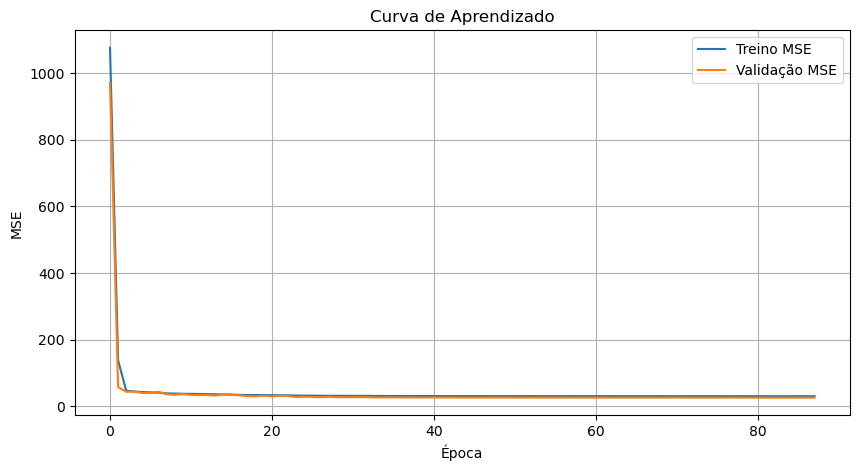

In [10]:
y_pred = final_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ MAE no Teste: {mae:.2f}")
print(f"✅ RMSE no Teste: {rmse:.2f}")
print(f"✅ R² Score Final: {r2:.4f}")

# Plotando histórico
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Treino MSE')
plt.plot(history.history['val_loss'], label='Validação MSE')
plt.title('Curva de Aprendizado')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import joblib
final_model.save('data/modelo_preditivo_tt05_rul.keras')
joblib.dump(scaler, 'data/scaler_tt05.pkl')
print("Modelo de 0.84 salvo com sucesso!")

Modelo de 0.84 salvo com sucesso!
